In [11]:
import os
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
import librosa.display
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [12]:
def create_mfcc(segmented_dir, n_mfcc=13, hop_length=512):
    segmented_dir = Path(segmented_dir)
    X = []
    y = []
    labels = [f.name for f in segmented_dir.iterdir() if f.is_dir()]

    for label in tqdm(labels):
        for audio in (segmented_dir / label).iterdir():
            if audio.suffix == '.wav':
                signal, sr = librosa.load(audio, sr=None)
                n_fft = min(2048, len(signal))
                mfcc = librosa.feature.mfcc(y=signal, 
                                            sr=sr, 
                                            n_mfcc=n_mfcc, 
                                            n_fft=n_fft, 
                                            hop_length=hop_length)
                X.append(mfcc)
                y.append(label)

    X = np.array(X)
    X = np.expand_dims(X, axis=-1)

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

    return X, np.array(y), label_encoder

Import data for model

In [13]:
X, y, label_encoder = create_mfcc('IRMAS_segmented')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=1)

100%|██████████| 11/11 [08:49<00:00, 48.18s/it] 


Plot MFCC

In [14]:
def plot_mfcc(X, i=0, save_path=None):
    mfcc_sample = X[i, :, :, 0]
    librosa.display.specshow(mfcc_sample, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('MFCC')
    plt.xlabel('Time Frames')
    plt.ylabel('MFCC Coefficients')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

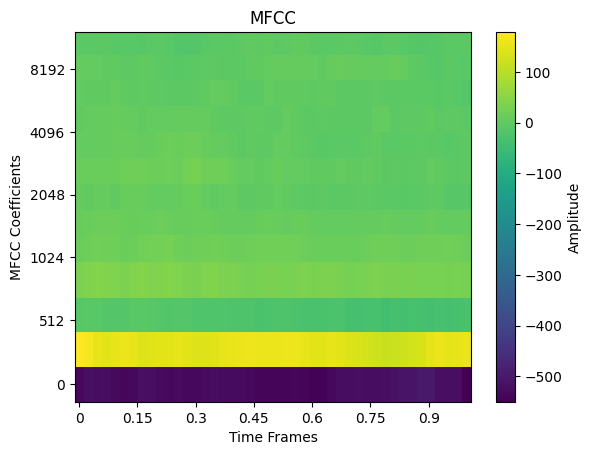

In [15]:
plot_mfcc(X)

CNN model

In [16]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

cnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2], 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2), padding='same'),
    layers.Dropout(0.4),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

cnn.compile(optimizer='adam',
            loss=losses.SparseCategoricalCrossentropy(),
            metrics=['accuracy'])

Train CNN

In [17]:
early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)

history = cnn.fit(
    X_train, y_train, 
    epochs=100, 
    validation_data=(X_val, y_val), 
    callbacks=[early_stopping], 
    class_weight=class_weights_dict
)

with open('IRMAS_cnn_mfcc_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.2336 - loss: 2.2255 - val_accuracy: 0.3687 - val_loss: 1.8444
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.3393 - loss: 1.9448 - val_accuracy: 0.4200 - val_loss: 1.7113
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.3747 - loss: 1.8338 - val_accuracy: 0.4669 - val_loss: 1.6014
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.4201 - loss: 1.7599 - val_accuracy: 0.4588 - val_loss: 1.6302
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4352 - loss: 1.7171 - val_accuracy: 0.4933 - val_loss: 1.5385
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.4487 - loss: 1.6581 - val_accuracy: 0.4995 - val_loss: 1.5112
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.4677 - loss: 1.6031 - val_accuracy: 0.4884 - val_loss: 1.5451
Epoch 8/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.4647 - loss: 1

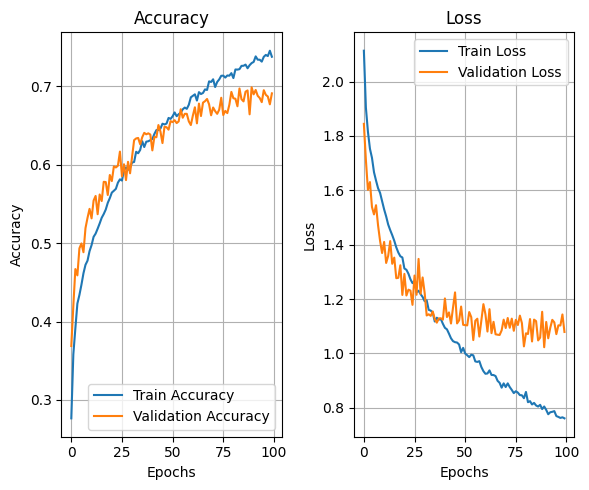

In [18]:
with open('IRMAS_cnn_mfcc_history.pkl', 'rb') as f:
    history = pickle.load(f)
    
plt.figure(figsize=(6, 5))

plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig('IRMAS_cnn_mfcc_training_curves.png')
plt.show()

Evaluate CNN

In [19]:
y_pred = cnn.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

accuracy = accuracy_score(y_test_labels, y_pred_labels)
class_report = classification_report(y_test_labels, y_pred_labels)

print('Accuracy:', accuracy)
print('\nClassification Report:\n', class_report)

output_file = 'IRMAS_cnn_mfcc_evaluation.txt'

with open(output_file, 'w') as file:
    file.write(f'Accuracy: {accuracy}\n')
    file.write('\nClassification Report:\n')
    file.write(class_report)

# best .69

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy: 0.6882923191648024

Classification Report:
               precision    recall  f1-score   support

         cel       0.63      0.86      0.73       233
         cla       0.64      0.63      0.63       303
         flu       0.53      0.59      0.56       270
         gac       0.66      0.85      0.74       382
         gel       0.70      0.67      0.68       456
         org       0.76      0.73      0.74       409
         pia       0.73      0.64      0.68       433
         sax       0.67      0.51      0.58       376
         tru       0.76      0.68      0.72       346
         vio       0.61      0.68      0.64       348
         voi       0.82      0.74      0.78       467

    accuracy                           0.69      4023
   macro avg       0.68      0.69      0.68      4023
weighted avg       0.69      0.69      0.69      4023



Save CNN

In [20]:
# cnn.save('cnn_mfcc_model.h5')